In [1]:
import os
import io
import sys
import json
import pickle
import random
import warnings
import webbrowser
from datetime import datetime, timedelta
from itertools import combinations
from collections import Counter
from multiprocessing import cpu_count
from typing import Any, Dict, Iterable, Tuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from matplotlib.transforms import Affine2D

import folium
from folium import plugins

import geopandas as gpd
import contextily as ctx

import holoviews as hv
from holoviews import opts
import hvplot
import hvplot.pandas

import plotly.graph_objects as go

import pygeohash as pgh
import torch

from joblib import Parallel, delayed
from tqdm import tqdm

from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
from shapely.prepared import prep

from pyproj import Transformer

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.manifold import SpectralEmbedding
from sklearn.metrics import silhouette_score

from scipy.stats import multivariate_normal, chi2
from scipy.spatial import cKDTree

from threadpoolctl import threadpool_limits

try:
    from IPython.display import display, HTML, IFrame
    _HAS_IPY = True
except Exception:
    _HAS_IPY = False

warnings.filterwarnings("ignore")


<MARK>
The following link needs to be updated in order to load the correct dataset of the AIS data. The link to download the dataset can be found in the README.md file of the preface directory.

In [2]:
%%time
csv_path = r"C:\Users\iliag\Desktop\MSc_DELFT\YEAR_2\Q2\Machine learning AI\Project\VS_CODE\Data\ProjectData_AIS_LA_2025.csv"

df = pd.read_csv(csv_path)

print(f"AIS dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns.")
df.head()


AIS dataset loaded: 4,056,967 rows × 17 columns.
CPU times: total: 6.77 s
Wall time: 6.81 s


,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Status,Length,Width,Draft,Cargo,TransceiverClass
0,366988970,2024-08-12T00:00:04,33.76708,-118.22046,0.0,271.9,121.0,LARCONA,NaN,WDC2171,31.0,0.0,21.0,7.0,3.2,31.0,A
1,367401030,2024-08-12T00:00:04,33.75408,-118.26853,0.1,16.3,88.0,DELTA BILLIE,IMO9562207,WDE8059,31.0,0.0,30.0,12.0,5.5,31.0,A
2,367452280,2024-08-12T00:00:04,33.73528,-118.26908,0.0,360.0,511.0,LAGUNA,NaN,WDL6144,52.0,0.0,60.0,19.0,2.5,52.0,A
3,367580930,2024-08-12T00:00:00,33.73759,-118.16589,23.3,116.1,511.0,TRIUMPHANT,IMO9759692,WDG8773,60.0,0.0,26.0,10.0,0.0,60.0,A
4,367691660,2024-08-12T00:00:07,33.74880,-118.11409,0.0,270.0,511.0,BIBI,NaN,WDI3764,37.0,7.0,19.0,5.0,0.0,30.0,A


1. Preprocess data like the paper (space, time, type, speed, heading, hourly)

In [3]:
%%time
time_col = "BaseDateTime"

df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col])

lat_min, lat_max = 33.60, 33.85
lon_min, lon_max = -118.45, -118.15
start = pd.Timestamp("2024-08-01 00:00:00")
end = pd.Timestamp("2024-08-31 00:00:00")

df["SOG"] = pd.to_numeric(df["SOG"], errors="coerce")

mask = (
    df["LAT"].between(lat_min, lat_max)
    & df["LON"].between(lon_min, lon_max)
    & df[time_col].ge(start)
    & df[time_col].lt(end)
    & (df["VesselType"].between(70, 79) | df["VesselType"].between(80, 89))
    & df["SOG"].lt(1)
)

df_f = df.loc[mask].copy()

df_f["Length"] = pd.to_numeric(df_f["Length"], errors="coerce")
df_f["Width"] = pd.to_numeric(df_f["Width"], errors="coerce")
df_f["Heading"] = pd.to_numeric(df_f["Heading"], errors="coerce")

df_f = df_f.loc[
    df_f["Length"].gt(0)
    & df_f["Width"].gt(0)
    & df_f["Heading"].notna()
    & df_f["Heading"].ne(511)
].copy()

df_f = df_f.sort_values(["MMSI", time_col])

d_heading = df_f.groupby("MMSI")["Heading"].diff().abs()
d_heading = d_heading.where(d_heading.isna(), np.minimum(d_heading, 360 - d_heading))
df_f = df_f.loc[d_heading.isna() | d_heading.le(10)].copy()

df_hour = (
    df_f.drop_duplicates(subset=["MMSI", time_col], keep="last")
    .set_index(time_col)
    .groupby("MMSI")
    .resample("1h")
    .last()
)

df_hour = df_hour.drop(columns=["MMSI"], errors="ignore").reset_index()

df_hour["LAT_original"] = df_hour["LAT"]
df_hour["LON_original"] = df_hour["LON"]

lat_mean = df_hour["LAT"].mean()
lat_std = df_hour["LAT"].std()
lon_mean = df_hour["LON"].mean()
lon_std = df_hour["LON"].std()

df_hour["LAT"] = (df_hour["LAT"] - lat_mean) / lat_std
df_hour["LON"] = (df_hour["LON"] - lon_mean) / lon_std

standardization_params = {
    "lat_mean": lat_mean,
    "lat_std": lat_std,
    "lon_mean": lon_mean,
    "lon_std": lon_std,
}


CPU times: total: 4.86 s
Wall time: 4.87 s


2. Convert to GeoDataFrame

In [4]:
%%time
cols_keep = [
    "MMSI",
    time_col,
    "LAT",
    "LON",
    "LAT_original",
    "LON_original",
    "SOG",
    "Heading",
    "VesselType",
    "Length",
    "Width",
]

df_clean = df_hour.loc[:, cols_keep].dropna(subset=["LAT", "LON"]).copy()

summary = pd.Series(
    {
        "rows": df_clean.shape[0],
        "cols": df_clean.shape[1],
        "memory_mb": df_clean.memory_usage(deep=True).sum() / 1e6,
        "lat_mean": df_clean["LAT"].mean(),
        "lat_std": df_clean["LAT"].std(),
        "lon_mean": df_clean["LON"].mean(),
        "lon_std": df_clean["LON"].std(),
        "lat_orig_min": df_clean["LAT_original"].min(),
        "lat_orig_max": df_clean["LAT_original"].max(),
        "lon_orig_min": df_clean["LON_original"].min(),
        "lon_orig_max": df_clean["LON_original"].max(),
        "length_min": df_clean["Length"].min(),
        "length_max": df_clean["Length"].max(),
        "width_min": df_clean["Width"].min(),
        "width_max": df_clean["Width"].max(),
    }
)

summary


CPU times: total: 15.6 ms
Wall time: 9.53 ms


rows            2.679200e+04
cols            1.100000e+01
memory_mb       2.572032e+00
lat_mean       -3.498357e-13
lat_std         1.000000e+00
lon_mean       -3.132414e-13
lon_std         1.000000e+00
lat_orig_min    3.369754e+01
lat_orig_max    3.377588e+01
lon_orig_min   -1.182817e+02
lon_orig_max   -1.181500e+02
length_min      4.500000e+01
length_max      4.000000e+02
width_min       1.500000e+01
width_max       6.000000e+01
dtype: float64

In [5]:
%%time
output_filename = "preprocessed_la_port_cargo_tanker.csv"
df_clean.to_csv(output_filename, index=False)

with open("standardization_params.json", "w") as f:
    json.dump(standardization_params, f, indent=2)

pd.Series(
    {
        "output_csv": output_filename,
        "rows": df_clean.shape[0],
        "cols": df_clean.shape[1],
        "unique_vessels": df_clean["MMSI"].nunique(),
        "date_range_days": (df_clean[time_col].max() - df_clean[time_col].min()).days,
        "saved_columns": list(df_clean.columns),
    }
)


CPU times: total: 219 ms
Wall time: 221 ms


output_csv                     preprocessed_la_port_cargo_tanker.csv
rows                                                           26792
cols                                                              11
unique_vessels                                                   363
date_range_days                                                   29
saved_columns      [MMSI, BaseDateTime, LAT, LON, LAT_original, L...
dtype: object

4. Visualize points over Port of LA map

CPU times: total: 0 ns
Wall time: 0 ns


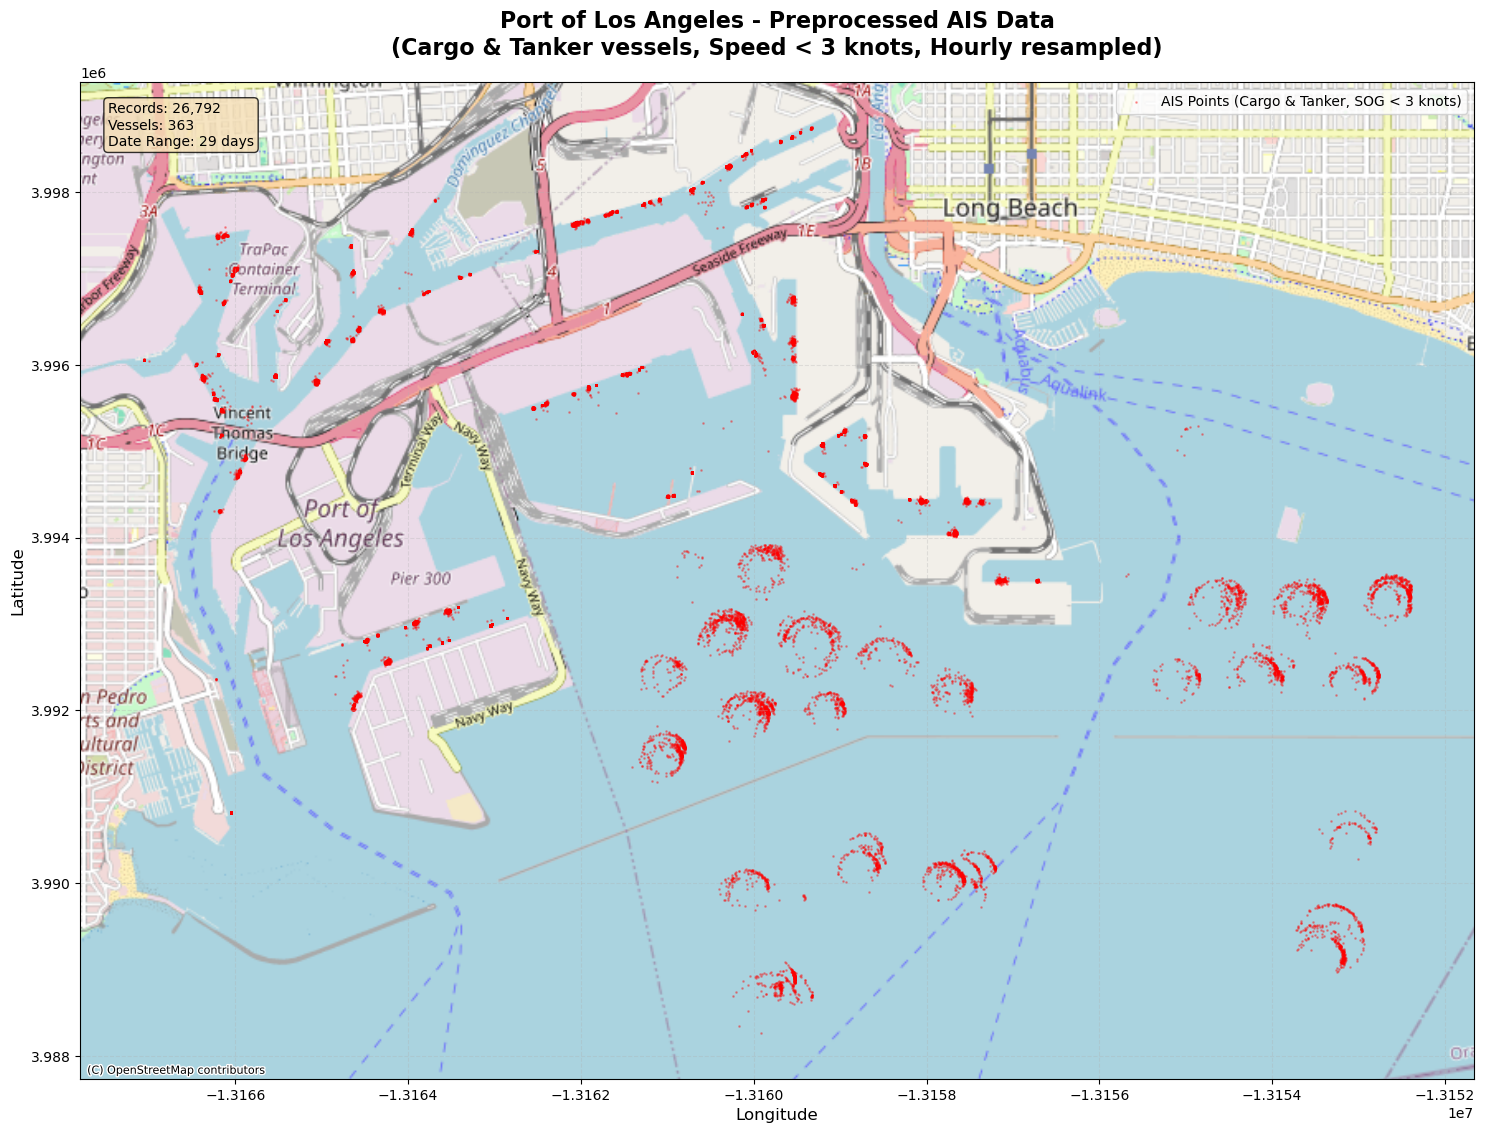

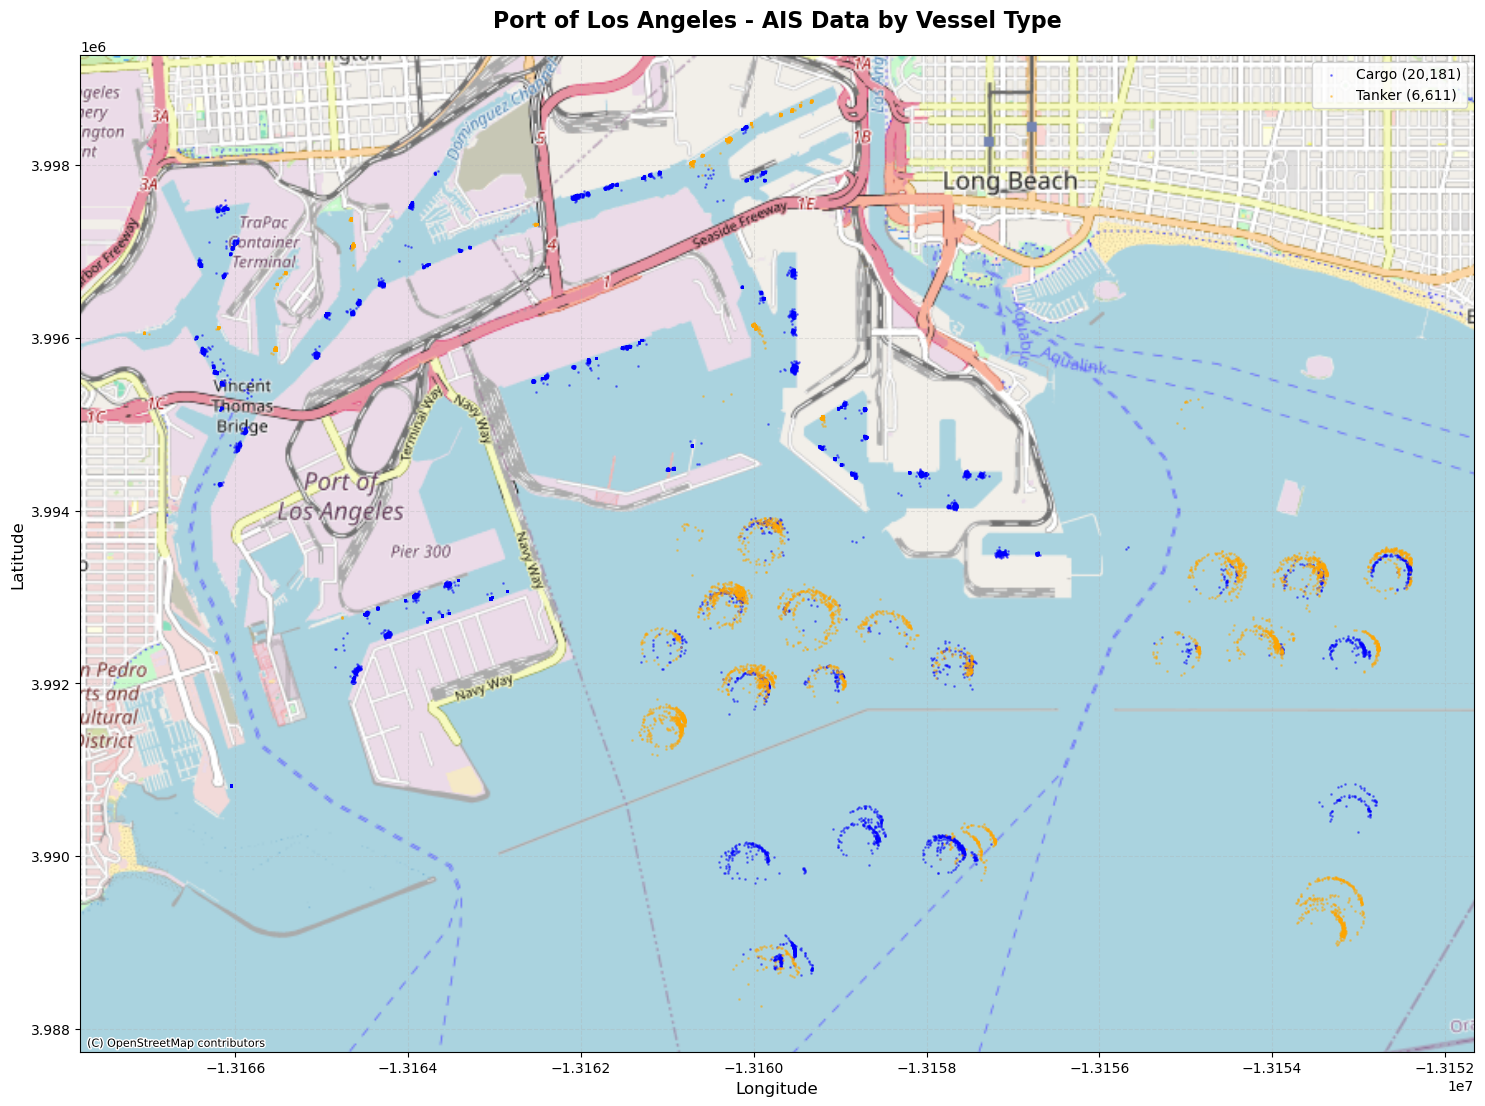

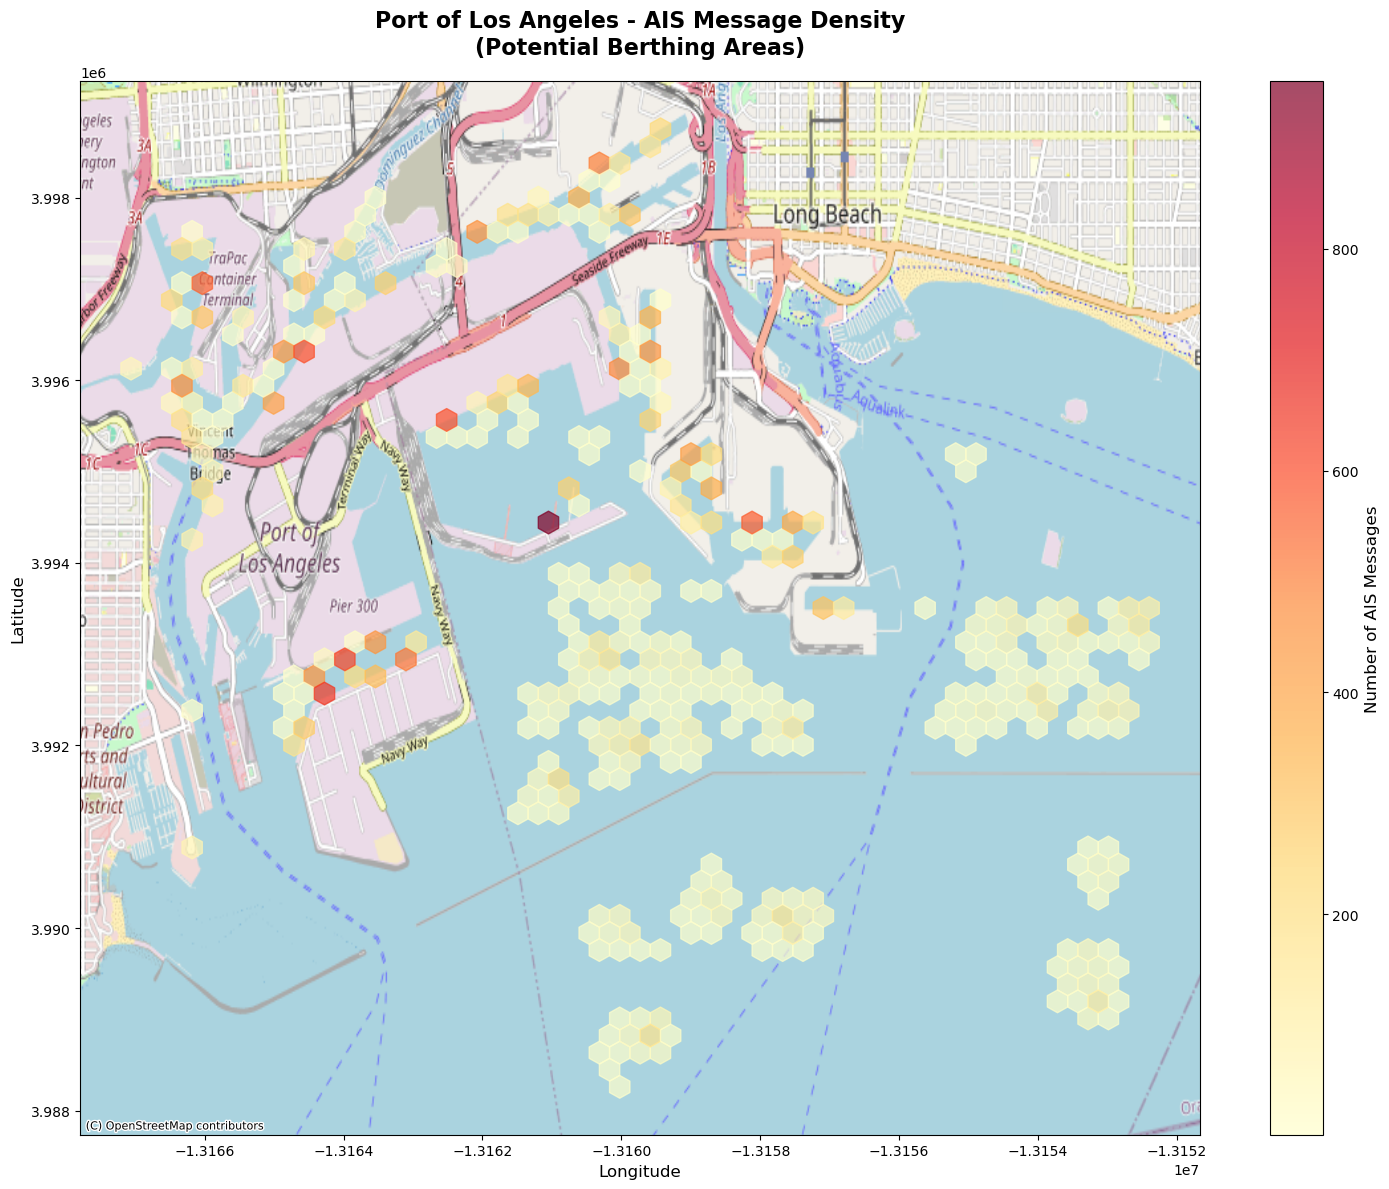

In [6]:
%time
time_col = "BaseDateTime"

gdf_viz = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean["LON_original"], df_clean["LAT_original"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)

records = len(df_clean)
vessels = df_clean["MMSI"].nunique()
date_range_days = (df_clean[time_col].max() - df_clean[time_col].min()).days

fig, ax = plt.subplots(figsize=(15, 12))
gdf_viz.plot(
    ax=ax,
    markersize=1,
    alpha=0.3,
    color="red",
    label="AIS Points (Cargo & Tanker, SOG < 3 knots)",
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=13, attribution_size=8)

ax.set_title(
    "Port of Los Angeles - Preprocessed AIS Data\n"
    "(Cargo & Tanker vessels, Speed < 3 knots, Hourly resampled)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")

ax.text(
    0.02,
    0.98,
    f"Records: {records:,}\nVessels: {vessels}\nDate Range: {date_range_days} days",
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

plt.tight_layout()
plt.savefig("port_la_ais_overview.png", dpi=300, bbox_inches="tight")
plt.show()

cargo = gdf_viz[gdf_viz["VesselType"].between(70, 79)]
tanker = gdf_viz[gdf_viz["VesselType"].between(80, 89)]

fig, ax = plt.subplots(figsize=(15, 12))
cargo.plot(ax=ax, markersize=1, alpha=0.4, color="blue", label=f"Cargo ({len(cargo):,})")
tanker.plot(ax=ax, markersize=1, alpha=0.4, color="orange", label=f"Tanker ({len(tanker):,})")

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=13, attribution_size=8)

ax.set_title("Port of Los Angeles - AIS Data by Vessel Type", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("port_la_ais_by_type.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(15, 12))
x = gdf_viz.geometry.x
y = gdf_viz.geometry.y

hexbin = ax.hexbin(x, y, gridsize=50, cmap="YlOrRd", mincnt=1, alpha=0.7)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=13, attribution_size=8)

cb = plt.colorbar(hexbin, ax=ax)
cb.set_label("Number of AIS Messages", fontsize=12)

ax.set_title(
    "Port of Los Angeles - AIS Message Density\n(Potential Berthing Areas)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

plt.tight_layout()
plt.savefig("port_la_ais_density.png", dpi=300, bbox_inches="tight")
plt.show()


4 WAY SPLIT

In [7]:
df_preprocessed = pd.read_csv("preprocessed_la_port_cargo_tanker.csv")

df_preprocessed["BaseDateTime"] = pd.to_datetime(df_preprocessed["BaseDateTime"], errors="coerce")
df_preprocessed["LAT"] = pd.to_numeric(df_preprocessed["LAT"], errors="coerce")
df_preprocessed["LON"] = pd.to_numeric(df_preprocessed["LON"], errors="coerce")
df_preprocessed = df_preprocessed.dropna(subset=["LAT", "LON"]).copy()

vessel_counts = df_preprocessed.groupby("MMSI").size().sort_values(ascending=False)

split_ids = (np.arange(len(vessel_counts)) % 2).astype(int)
split_assignment = pd.Series(split_ids, index=vessel_counts.index)

df_preprocessed["split"] = df_preprocessed["MMSI"].map(split_assignment).astype(int)

splits = [df_preprocessed.loc[df_preprocessed["split"].eq(i)].copy() for i in range(2)]
split_0, split_1 = splits

print(f"Split 0: {len(split_0):,} rows, {split_0['MMSI'].nunique()} vessels")
print(f"Split 1: {len(split_1):,} rows, {split_1['MMSI'].nunique()} vessels")


Split 0: 13,617 rows, 182 vessels
Split 1: 13,175 rows, 181 vessels


KNN for outlier filtering

In [8]:
K_MIN = 40
K_MAX = 101
RANDOM_SEED = 42
MAX_ITER = 1000
N_INIT = 20
PLATEAU_THRESHOLD = 0.01
PLATEAU_COUNT = 3
N_JOBS = -1

N_NEIGHBORS_GRAPH = 25

splits_for_kmeans = [split_0, split_1]
K_RANGE = range(K_MIN, K_MAX)


def _row_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)


def _discretize_labels(
    X: np.ndarray,
    random_state: int,
    n_iter: int = 20,
) -> Tuple[np.ndarray, float]:
    rng = np.random.RandomState(int(random_state))
    N, K = X.shape

    R = rng.normal(size=(K, K))
    U, _, Vt = np.linalg.svd(R, full_matrices=False)
    R = U @ Vt

    best_trace = -np.inf
    labels = np.zeros(N, dtype=int)

    for _ in range(int(n_iter)):
        T = X @ R
        labels = np.argmax(T, axis=1)

        Y = np.zeros((N, K), dtype=float)
        Y[np.arange(N), labels] = 1.0

        M = Y.T @ X
        U, S, Vt = np.linalg.svd(M, full_matrices=False)
        R = Vt.T @ U.T

        tr = float(np.sum(S))
        if tr <= best_trace + 1e-12:
            break
        best_trace = tr

    return labels, best_trace


def _discretize_best_of_n(
    X: np.ndarray,
    K: int,
    n_init: int,
    base_seed: int,
) -> np.ndarray:
    best_trace = -np.inf
    best_labels = None

    for run in range(int(n_init)):
        seed = int(base_seed + run * 1000 + K)
        labels, tr = _discretize_labels(X, seed)
        if tr > best_trace:
            best_trace = tr
            best_labels = labels

    return best_labels


def _sse_proxy(data: np.ndarray, labels: np.ndarray, K: int) -> float:
    sse = 0.0
    for k in range(K):
        mask = labels == k
        if np.any(mask):
            mu = data[mask].mean(axis=0)
            diff = data[mask] - mu
            sse += float(np.sum(diff * diff))
    return sse


def spectral_fit_once_per_split(
    data: np.ndarray,
    n_components: int,
    n_neighbors_graph: int,
    random_state: int,
) -> np.ndarray:
    model = SpectralEmbedding(
        n_components=int(n_components),
        affinity="nearest_neighbors",
        n_neighbors=int(n_neighbors_graph),
        random_state=int(random_state),
    )
    return model.fit_transform(data)


def run_single_split(
    data: np.ndarray,
    K_range: Iterable[int],
    split_idx: int,
    n_neighbors_graph: int = N_NEIGHBORS_GRAPH,
) -> Tuple[pd.DataFrame, Dict[int, Dict[str, Any]]]:
    K_list = list(K_range)
    K_max = int(max(K_list))

    N = int(data.shape[0])
    if N == 0:
        summary_df = pd.DataFrame({"K": K_list, "final_J": np.inf, "converged_iteration": 0})
        all_results = {K: {"means": np.empty((0, 2)), "labels": np.empty((0,), dtype=int), "J": float("inf")} for K in K_list}
        return summary_df, all_results

    n_components = int(min(K_max, max(1, N - 1)))
    U = spectral_fit_once_per_split(
        data=data,
        n_components=n_components,
        n_neighbors_graph=min(int(n_neighbors_graph), max(1, N - 1)),
        random_state=int(RANDOM_SEED + split_idx),
    )

    final_J = []
    conv_it = []
    all_results: Dict[int, Dict[str, Any]] = {}

    for K in tqdm(K_list, desc=f"Split {split_idx}", position=split_idx):
        K = int(K)
        if K > n_components or N < K:
            labels = np.full(N, -1, dtype=int)
            means = np.full((K, data.shape[1]), np.nan, dtype=float)
            J = float("inf")
        else:
            Xk = _row_normalize(U[:, :K].copy())
            labels = _discretize_best_of_n(Xk, K, N_INIT, RANDOM_SEED)
            means = np.full((K, data.shape[1]), np.nan, dtype=float)
            for k in range(K):
                mask = labels == k
                if np.any(mask):
                    means[k] = data[mask].mean(axis=0)
            J = _sse_proxy(data, labels, K)

        all_results[K] = {"means": means, "labels": labels, "J": J}
        final_J.append(J)
        conv_it.append(0)

    summary_df = pd.DataFrame(
        {"K": K_list, "final_J": final_J, "converged_iteration": conv_it}
    ).sort_values("K", ignore_index=True)

    return summary_df, all_results


def process_split(split_idx: int, split_df: pd.DataFrame, K_range: Iterable[int]) -> Dict[str, Any]:
    data = split_df[["LON", "LAT"]].to_numpy(dtype=float)
    summary_df, results = run_single_split(data, K_range, split_idx, n_neighbors_graph=N_NEIGHBORS_GRAPH)
    return {
        "split_idx": int(split_idx),
        "summary": summary_df,
        "all_results": results,
        "n_points": int(data.shape[0]),
        "n_vessels": int(split_df["MMSI"].nunique()),
    }


def find_valid_K_range(all_split_results, K_range, threshold: float = PLATEAU_THRESHOLD, count: int = PLATEAU_COUNT):
    K_values = np.array(list(K_range))
    n_splits = len(all_split_results)

    improvements = np.zeros((n_splits, len(K_values) - 1), dtype=float)
    for split_idx in range(n_splits):
        J_vals = all_split_results[split_idx]["summary"]["final_J"].to_numpy()
        improvements[split_idx] = (J_vals[:-1] - J_vals[1:]) / np.maximum(J_vals[:-1], 1e-12)

    all_below = np.all(improvements < threshold, axis=0)

    max_valid_idx = len(K_values) - 1
    consecutive = 0
    for i, ok in enumerate(all_below):
        consecutive = consecutive + 1 if ok else 0
        if consecutive >= count:
            max_valid_idx = i + 1 - count
            break

    return int(K_values[max_valid_idx]), improvements


def find_optimal_K(all_split_results, K_range, max_valid_K: int):
    K_values = np.array(list(K_range))
    valid_mask = K_values <= max_valid_K
    if not np.any(valid_mask):
        return {"optimal_K": int(K_values[0]), "max_valid_K": int(max_valid_K)}

    n_splits = len(all_split_results)
    normalized_J = np.zeros((n_splits, len(K_values)), dtype=float)

    for split_idx in range(n_splits):
        J_vals = all_split_results[split_idx]["summary"]["final_J"].to_numpy()
        denom = J_vals.max() - J_vals.min()
        normalized_J[split_idx] = (J_vals - J_vals.min()) / (denom if denom != 0 else 1.0)

    variance_per_K = np.var(normalized_J, axis=0)
    optimal_idx = int(np.argmin(variance_per_K[valid_mask]))
    optimal_K = int(K_values[valid_mask][optimal_idx])
    full_idx = int(np.where(K_values == optimal_K)[0][0])

    return {
        "optimal_K": optimal_K,
        "max_valid_K": int(max_valid_K),
        "variance": float(variance_per_K[full_idx]),
        "mean_normalized_J": float(np.mean(normalized_J[:, full_idx])),
        "normalized_J_values": normalized_J[:, full_idx],
    }


outer_jobs = min(4, max(1, cpu_count() // 2))

split_results_list = Parallel(n_jobs=outer_jobs)(
    delayed(process_split)(split_idx, split_df, K_RANGE)
    for split_idx, split_df in enumerate(splits_for_kmeans)
)

all_split_results = {res["split_idx"]: res for res in split_results_list}

max_valid_K, improvements = find_valid_K_range(all_split_results, K_RANGE)
metrics = find_optimal_K(all_split_results, K_RANGE, max_valid_K)

OPTIMAL_K = metrics["optimal_K"]
SPECTRAL_RESULTS = {
    f"split_{i}": {
        "K": OPTIMAL_K,
        "means": all_split_results[i]["all_results"][OPTIMAL_K]["means"],
        "labels": all_split_results[i]["all_results"][OPTIMAL_K]["labels"],
        "J": all_split_results[i]["all_results"][OPTIMAL_K]["J"],
    }
    for i in range(len(splits_for_kmeans))
}

pd.Series(
    {
        "K_min": K_MIN,
        "K_max_exclusive": K_MAX,
        "n_init": N_INIT,
        "cpu_cores": cpu_count(),
        "outer_jobs": outer_jobs,
        "n_neighbors_graph": N_NEIGHBORS_GRAPH,
        "max_valid_K": max_valid_K,
        "optimal_K": OPTIMAL_K,
        "variance_at_optimal_K": metrics.get("variance", np.nan),
    }
)


K_min                     40.0
K_max_exclusive          101.0
n_init                    20.0
cpu_cores                 16.0
outer_jobs                 4.0
n_neighbors_graph         25.0
max_valid_K              100.0
optimal_K                 99.0
variance_at_optimal_K      0.0
dtype: float64

Add Dimensions

In [9]:
for split_df in (split_0, split_1):
    split_df["DimensionA"] = split_df["Length"] / 2
    split_df["DimensionB"] = split_df["Length"] / 2
    split_df["DimensionC"] = split_df["Width"] / 2
    split_df["DimensionD"] = split_df["Width"] / 2


Spatial Augmentation

In [10]:
with open("standardization_params.json", "r") as f:
    std_params = json.load(f)

def generate_augmented_points(df: pd.DataFrame, n_points: int = 10) -> pd.DataFrame:
    augmented = []
    skipped = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Augmenting", unit="msg"):
        heading = row["Heading"]
        if pd.isna(heading) or heading < 0 or heading > 360:
            skipped += 1
            continue

        dim_a = row["DimensionA"]
        dim_b = row["DimensionB"]
        dim_c = row["DimensionC"]
        dim_d = row["DimensionD"]

        if any(pd.isna([dim_a, dim_b, dim_c, dim_d])) or any(v <= 0 for v in (dim_a, dim_b, dim_c, dim_d)):
            skipped += 1
            continue

        if (dim_a + dim_b) > 500 or (dim_c + dim_d) > 100:
            skipped += 1
            continue

        lat_orig = row["LAT_original"]
        lon_orig = row["LON_original"]

        heading_rad = np.radians(heading)
        meters_per_degree_lat = 111000.0
        meters_per_degree_lon = 111000.0 * np.cos(np.radians(lat_orig))

        max_offset_lat = ((dim_a + dim_b) * 1.5) / meters_per_degree_lat
        max_offset_lon = ((dim_c + dim_d) * 1.5) / meters_per_degree_lon

        for _ in range(n_points):
            x_local = np.random.uniform(-dim_b, dim_a)
            y_local = np.random.uniform(-dim_c, dim_d)

            x_global = x_local * np.sin(heading_rad) + y_local * np.cos(heading_rad)
            y_global = x_local * np.cos(heading_rad) - y_local * np.sin(heading_rad)

            lat_offset_deg = y_global / meters_per_degree_lat
            lon_offset_deg = x_global / meters_per_degree_lon

            new_lat_orig = lat_orig + lat_offset_deg
            new_lon_orig = lon_orig + lon_offset_deg

            if (abs(new_lat_orig - lat_orig) > max_offset_lat) or (abs(new_lon_orig - lon_orig) > max_offset_lon):
                continue

            aug = row.copy()
            aug["LAT_original"] = new_lat_orig
            aug["LON_original"] = new_lon_orig
            aug["LAT"] = (new_lat_orig - std_params["lat_mean"]) / std_params["lat_std"]
            aug["LON"] = (new_lon_orig - std_params["lon_mean"]) / std_params["lon_std"]
            aug["is_augmented"] = True
            augmented.append(aug)

        orig = row.copy()
        orig["is_augmented"] = False
        augmented.append(orig)

    if skipped:
        print(f"Skipped {skipped} points due to invalid heading/dimensions")

    return pd.DataFrame(augmented)


N_POINTS_TRAINING = 10

split_0_augmented = generate_augmented_points(split_0, n_points=N_POINTS_TRAINING)
split_1_augmented = generate_augmented_points(split_1, n_points=N_POINTS_TRAINING)


splits_augmented = [split_0_augmented, split_1_augmented]

Augmenting: 100%|██████████| 13175/13175 [00:23<00:00, 572.19msg/s]


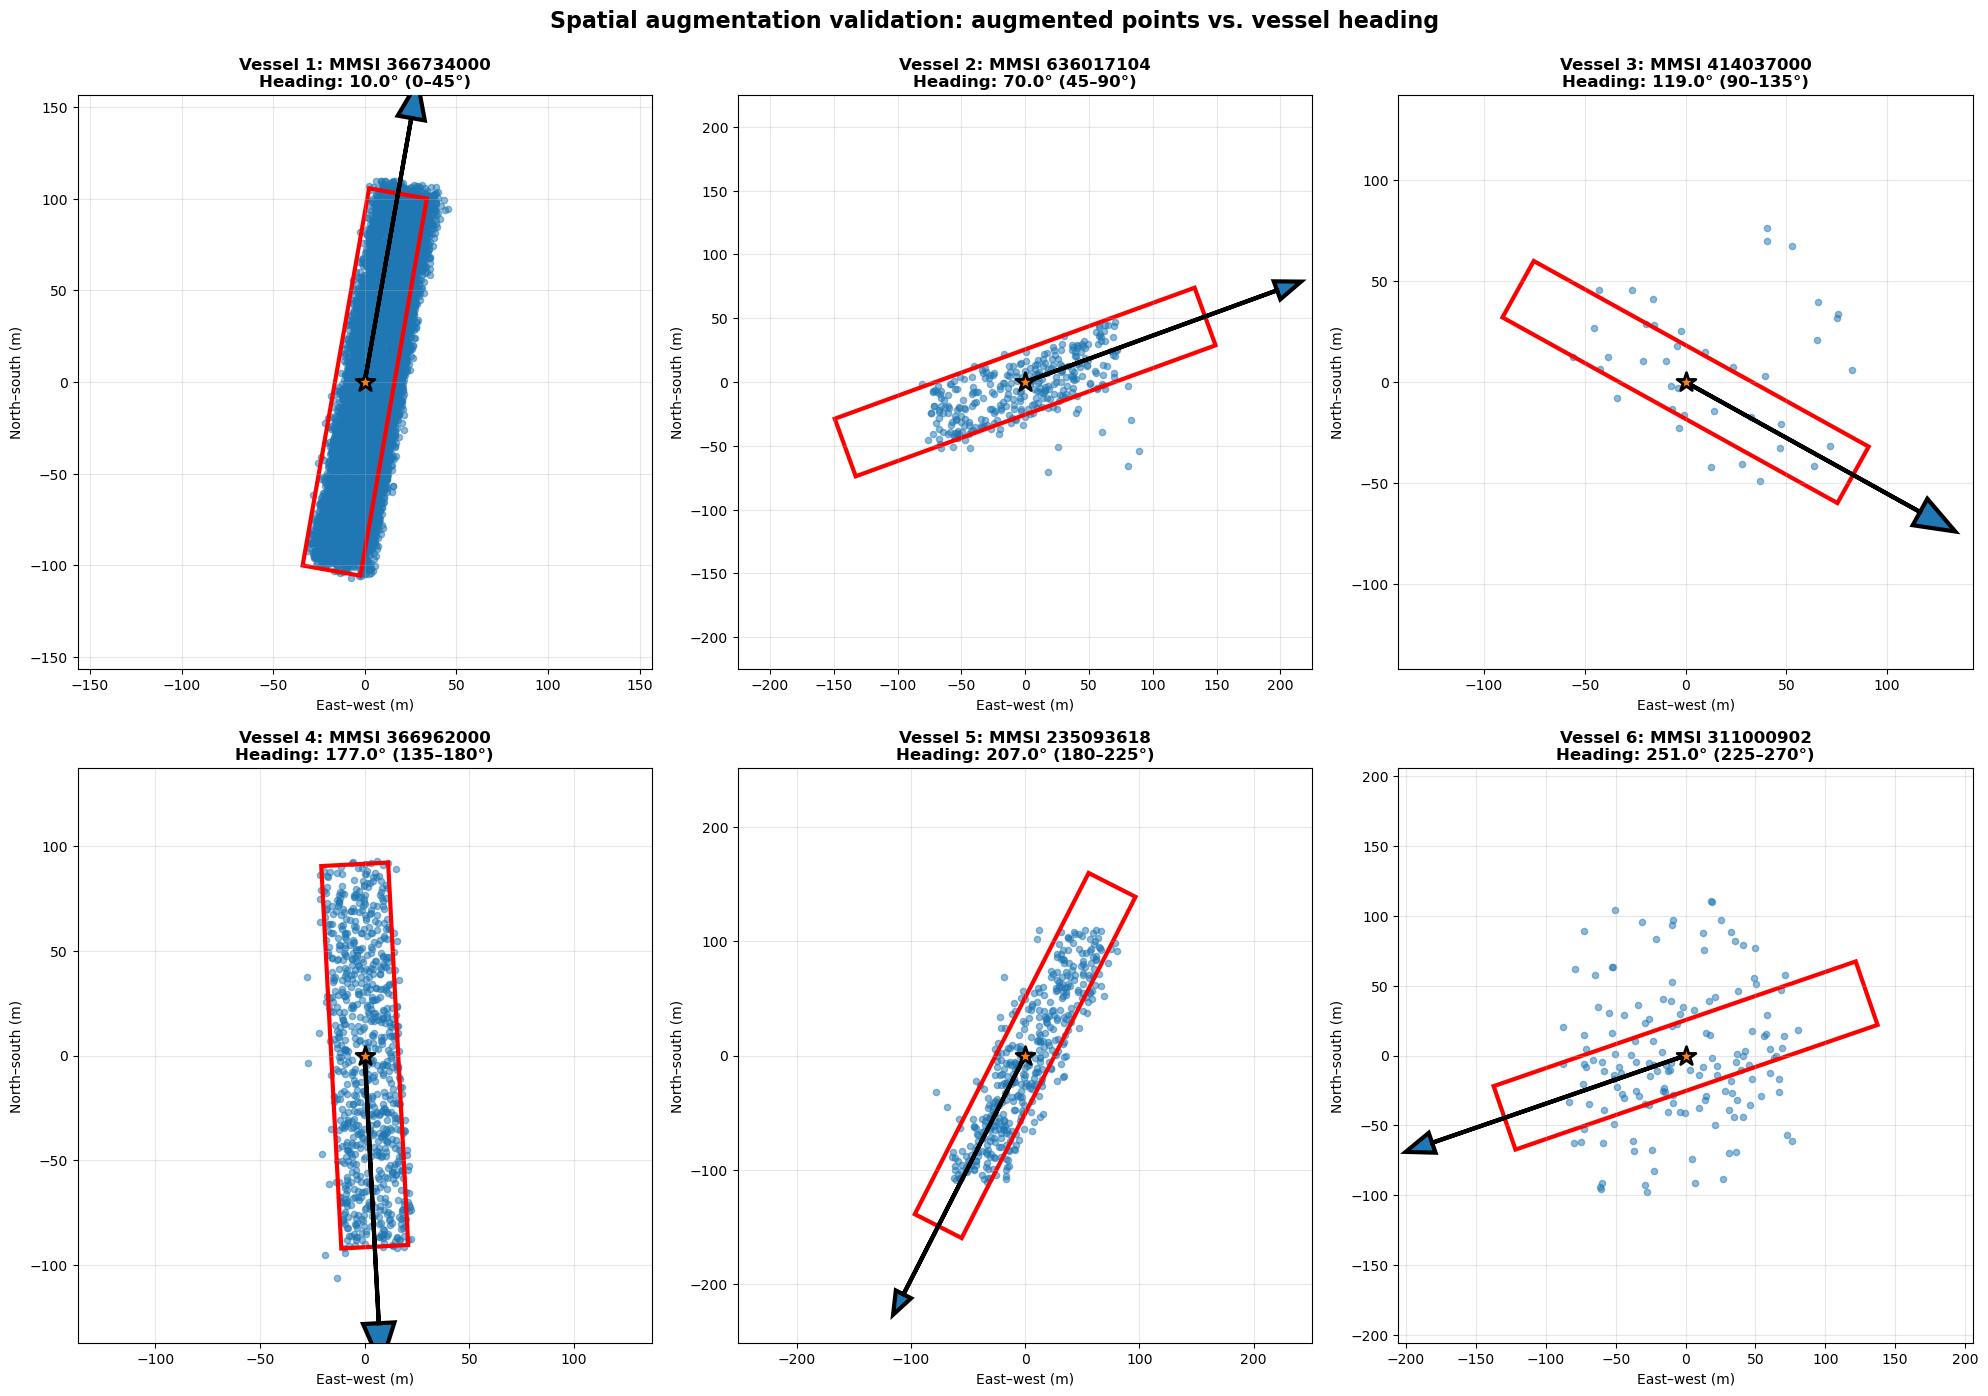

CPU times: total: 766 ms
Wall time: 743 ms


split_0    6.929133
split_1    6.411841
dtype: float64

In [11]:
%%time
original_points = split_0_augmented.loc[~split_0_augmented["is_augmented"]].copy()

heading_ranges = [
    (0, 45, "0–45°"),
    (45, 90, "45–90°"),
    (90, 135, "90–135°"),
    (135, 180, "135–180°"),
    (180, 225, "180–225°"),
    (225, 270, "225–270°"),
    (270, 315, "270–315°"),
    (315, 360, "315–360°"),
]

vessels_to_plot = []
for h_min, h_max, label in heading_ranges:
    candidates = original_points.loc[original_points["Heading"].between(h_min, h_max, inclusive="left")]
    if len(candidates):
        vessels_to_plot.append((candidates.sample(1).iloc[0], label))
    if len(vessels_to_plot) >= 6:
        break

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

def to_meters(lat, lon, lat_ref, lon_ref):
    lat_m = (lat - lat_ref) * 111000.0
    lon_m = (lon - lon_ref) * 111000.0 * np.cos(np.radians(lat_ref))
    return lon_m, lat_m

for idx, (vessel, heading_label) in enumerate(vessels_to_plot[:6]):
    ax = axes[idx]

    mmsi = vessel["MMSI"]
    heading = vessel["Heading"]
    lat_orig = vessel["LAT_original"]
    lon_orig = vessel["LON_original"]

    dim_a = vessel["DimensionA"]
    dim_b = vessel["DimensionB"]
    dim_c = vessel["DimensionC"]
    dim_d = vessel["DimensionD"]

    vessel_data = split_0_augmented.loc[
        (split_0_augmented["MMSI"] == mmsi)
        & (np.abs(split_0_augmented["LAT_original"] - lat_orig) < 0.001)
        & (np.abs(split_0_augmented["LON_original"] - lon_orig) < 0.001)
    ]

    augmented = vessel_data.loc[vessel_data["is_augmented"]]

    if len(augmented):
        aug_x, aug_y = to_meters(
            augmented["LAT_original"].to_numpy(),
            augmented["LON_original"].to_numpy(),
            lat_orig,
            lon_orig,
        )
        ax.scatter(aug_x, aug_y, s=20, alpha=0.5, label="Augmented points")

    ax.scatter([0], [0], s=200, marker="*", edgecolors="black", linewidths=2, label="Original AIS", zorder=10)

    vessel_length = dim_a + dim_b
    vessel_width = dim_c + dim_d

    rect = Rectangle(
        (-dim_b, -dim_c),
        vessel_length,
        vessel_width,
        linewidth=3,
        edgecolor="red",
        facecolor="none",
        label="Vessel footprint",
    )
    rect.set_transform(Affine2D().rotate_deg(90 - heading) + ax.transData)
    ax.add_patch(rect)

    arrow_length = max(vessel_length, vessel_width) * 0.7
    heading_rad = np.radians(heading)
    ax.arrow(
        0,
        0,
        arrow_length * np.sin(heading_rad),
        arrow_length * np.cos(heading_rad),
        head_width=15,
        head_length=20,
        linewidth=3,
        zorder=5,
    )

    ax.set_xlabel("East–west (m)")
    ax.set_ylabel("North–south (m)")
    ax.set_title(f"Vessel {idx+1}: MMSI {mmsi}\nHeading: {heading:.1f}° ({heading_label})", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

    max_range = max(vessel_length, vessel_width) * 1.5
    ax.set_xlim(-max_range / 2, max_range / 2)
    ax.set_ylim(-max_range / 2, max_range / 2)

for j in range(len(vessels_to_plot), 6):
    axes[j].axis("off")

plt.suptitle("Spatial augmentation validation: augmented points vs. vessel heading", fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

ratios = {}
for i, split in enumerate([split_0_augmented, split_1_augmented]):
    n_orig = int((~split["is_augmented"]).sum())
    n_aug = int((split["is_augmented"]).sum())
    ratios[f"split_{i}"] = (n_aug / n_orig) if n_orig else np.nan

pd.Series(ratios)


GEOHASH ENCODING

In [12]:
%%time
GEOHASH_PRECISION = 9

def circular_mean_degrees(angles: pd.Series) -> float:
    angles_rad = np.radians(angles.to_numpy(dtype=float))
    mean_rad = np.arctan2(np.mean(np.sin(angles_rad)), np.mean(np.cos(angles_rad)))
    mean_deg = np.degrees(mean_rad)
    return mean_deg + 360.0 if mean_deg < 0 else mean_deg


def apply_geohash_encoding(df: pd.DataFrame, precision: int = 9) -> pd.DataFrame:
    df_copy = df.copy()
    df_copy["geohash"] = [
        pgh.encode(lat, lon, precision=precision)
        for lat, lon in tqdm(
            zip(df_copy["LAT_original"].to_numpy(), df_copy["LON_original"].to_numpy()),
            total=len(df_copy),
            desc="Generating geohashes",
            unit="pt",
        )
    ]

    df_encoded = df_copy.groupby("geohash", as_index=False).agg(
        {
            "LAT": "mean",
            "LON": "mean",
            "LAT_original": "mean",
            "LON_original": "mean",
            "MMSI": "first",
            "Heading": circular_mean_degrees,
            "DimensionA": "first",
            "DimensionB": "first",
            "DimensionC": "first",
            "DimensionD": "first",
            "BaseDateTime": "first",
            "VesselType": "first",
            "is_augmented": "any",
        }
    )

    cell_counts = df_copy.groupby("geohash").size()
    df_encoded["points_per_cell"] = df_encoded["geohash"].map(cell_counts).astype(int)

    return df_encoded


splits_geohash = [
    apply_geohash_encoding(split_0_augmented, precision=GEOHASH_PRECISION),
    apply_geohash_encoding(split_1_augmented, precision=GEOHASH_PRECISION),
]

split_0_geohash, split_1_geohash = splits_geohash

summary = pd.DataFrame(
    {
        "split": [0, 1],
        "before": [len(split_0_augmented), len(split_1_augmented)],
        "after": [len(split_0_geohash), len(split_1_geohash)],
    }
)
summary["reduction_pct"] = 100.0 * (1.0 - summary["after"] / summary["before"])
summary


Generating geohashes: 100%|██████████| 97651/97651 [00:00<00:00, 674378.94pt/s]


CPU times: total: 3.55 s
Wall time: 3.57 s


,split,before,after,reduction_pct
0,0,107971,46011,57.385780
1,1,97651,46829,52.044526


SPECTRAL CLUSTERING - TRAINING


Note: 1st cell is training. 2nd cell is for loading the already created pkl file of the training.

1. Training the spectral clustering model - finding parameters - saving pkl file.

In [13]:
%%time

warnings.filterwarnings("ignore")

K_SEARCH_MIN = 10
K_SEARCH_MAX = 100
K_COARSE = range(10, 101, 10)
RANDOM_SEED = 42

N_NEIGHBORS_GRAPH = 25
N_INIT_DISCRETIZE = 5
DISCRETIZE_MAX_ITER = 25

SIL_SAMPLE_TRAIN = 3000
SIL_SAMPLE_VAL = 3000



def _row_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)


def _discretize_labels(X: np.ndarray, random_state: int, n_iter: int = DISCRETIZE_MAX_ITER) -> tuple[np.ndarray, float]:
    rng = np.random.RandomState(int(random_state))
    N, K = X.shape

    R = rng.normal(size=(K, K))
    U, _, Vt = np.linalg.svd(R, full_matrices=False)
    R = U @ Vt

    best_trace = -np.inf
    labels = np.zeros(N, dtype=int)

    for _ in range(int(n_iter)):
        T = X @ R
        labels = np.argmax(T, axis=1)

        Y = np.zeros((N, K), dtype=float)
        Y[np.arange(N), labels] = 1.0

        M = Y.T @ X
        U, S, Vt = np.linalg.svd(M, full_matrices=False)
        R = Vt.T @ U.T

        tr = float(np.sum(S))
        if tr <= best_trace + 1e-12:
            break
        best_trace = tr

    return labels, best_trace


def _discretize_best_of_n(X: np.ndarray, K: int, n_init: int, base_seed: int) -> np.ndarray:
    best_trace = -np.inf
    best_labels = None
    for run in range(int(n_init)):
        seed = int(base_seed + run * 1000 + K)
        labels, tr = _discretize_labels(X, seed)
        if tr > best_trace:
            best_trace = tr
            best_labels = labels
    return best_labels


def _spectral_embedding(coords: np.ndarray, n_components: int, n_neighbors: int, random_state: int) -> np.ndarray:
    N = int(coords.shape[0])
    if N == 0:
        return np.empty((0, 0), dtype=float)
    n_neighbors = int(min(max(1, n_neighbors), max(1, N - 1)))
    n_components = int(min(max(1, n_components), max(1, N - 1)))

    model = SpectralEmbedding(
        n_components=n_components,
        affinity="nearest_neighbors",
        n_neighbors=n_neighbors,
        random_state=int(random_state),
    )
    return model.fit_transform(coords)


def _silhouette_on_embedding(U: np.ndarray, labels: np.ndarray, sample_size: int, random_state: int) -> float:
    N = int(U.shape[0])
    if N == 0:
        return float("nan")
    if np.unique(labels).size < 2:
        return float("nan")
    s = int(min(sample_size, N))
    return float(silhouette_score(U, labels, sample_size=s, random_state=int(random_state)))


def _evaluate_K(U_full: np.ndarray, K: int, n_init: int, base_seed: int, sample_size: int) -> tuple[int, float]:
    K = int(K)
    if U_full.shape[0] <= K or U_full.shape[1] < K:
        return K, float("nan")
    X = _row_normalize(U_full[:, :K].copy())
    labels = _discretize_best_of_n(X, K, n_init, base_seed)
    sil = _silhouette_on_embedding(X, labels, sample_size=sample_size, random_state=base_seed + K)
    return K, sil


def three_phase_search(U_full: np.ndarray, split_name: str) -> tuple[int, float, list[tuple[int, float]]]:
    tested = set()
    all_scores: list[tuple[int, float]] = []

    best_n, best_sil = K_SEARCH_MIN, -np.inf

    for n in tqdm(list(K_COARSE), desc=f"{split_name} Phase 1", leave=False):
        k, sil = _evaluate_K(U_full, n, n_init=1, base_seed=RANDOM_SEED, sample_size=SIL_SAMPLE_TRAIN)
        tested.add(k)
        all_scores.append((k, sil))
        if np.isfinite(sil) and sil > best_sil:
            best_sil, best_n = sil, k

    medium_start = max(K_SEARCH_MIN, best_n - 10)
    medium_end = min(K_SEARCH_MAX, best_n + 10) + 1
    for n in tqdm(list(range(medium_start, medium_end, 2)), desc=f"{split_name} Phase 2", leave=False):
        if n in tested:
            continue
        k, sil = _evaluate_K(U_full, n, n_init=1, base_seed=RANDOM_SEED, sample_size=SIL_SAMPLE_TRAIN)
        tested.add(k)
        all_scores.append((k, sil))
        if np.isfinite(sil) and sil > best_sil:
            best_sil, best_n = sil, k

    fine_start = max(K_SEARCH_MIN, best_n - 10)
    fine_end = min(K_SEARCH_MAX, best_n + 10) + 1
    for n in tqdm(list(range(fine_start, fine_end, 1)), desc=f"{split_name} Phase 3", leave=False):
        if n in tested:
            continue
        k, sil = _evaluate_K(U_full, n, n_init=1, base_seed=RANDOM_SEED, sample_size=SIL_SAMPLE_TRAIN)
        tested.add(k)
        all_scores.append((k, sil))
        if np.isfinite(sil) and sil > best_sil:
            best_sil, best_n = sil, k

    all_scores = sorted(all_scores, key=lambda x: x[0])
    return int(best_n), float(best_sil), all_scores


def run_fold(val_idx: int) -> dict:
    # 2-fold CV: train on the other split
    train_indices = [i for i in range(2) if i != val_idx]
    train_df = pd.concat([splits_geohash[i] for i in train_indices], ignore_index=True)
    val_df = splits_geohash[val_idx]

    train_coords = train_df[["LON", "LAT"]].to_numpy(dtype=float)
    val_coords = val_df[["LON", "LAT"]].to_numpy(dtype=float)

    with threadpool_limits(limits=1):
        U_train = _spectral_embedding(
            coords=train_coords,
            n_components=K_SEARCH_MAX,
            n_neighbors=N_NEIGHBORS_GRAPH,
            random_state=RANDOM_SEED + val_idx,
        )

        optimal_n, train_search_sil, scores = three_phase_search(U_train, f"Fold {val_idx+1}")

        X_train = _row_normalize(U_train[:, :optimal_n].copy())
        train_labels = _discretize_best_of_n(X_train, optimal_n, N_INIT_DISCRETIZE, RANDOM_SEED)
        final_train_sil = _silhouette_on_embedding(
            X_train, train_labels, SIL_SAMPLE_TRAIN, RANDOM_SEED + 100 + val_idx
        )

        U_val = _spectral_embedding(
            coords=val_coords,
            n_components=optimal_n,
            n_neighbors=N_NEIGHBORS_GRAPH,
            random_state=RANDOM_SEED + 1000 + val_idx,
        )
        X_val = _row_normalize(U_val.copy())
        val_labels = _discretize_best_of_n(X_val, optimal_n, N_INIT_DISCRETIZE, RANDOM_SEED + 2000)
        val_sil = _silhouette_on_embedding(X_val, val_labels, SIL_SAMPLE_VAL, RANDOM_SEED + 200 + val_idx)

    return {
        "fold": int(val_idx),
        "val_split": int(val_idx),
        "train_splits": train_indices,
        "optimal_n": int(optimal_n),
        "train_search_silhouette": float(train_search_sil),
        "train_silhouette": float(final_train_sil),
        "val_silhouette": float(val_sil),
        "silhouette_diff": float(abs(final_train_sil - val_sil)),
        "train_labels": train_labels,
        "val_labels": val_labels,
        "scores": scores,
        "n_train": int(train_coords.shape[0]),
        "n_val": int(val_coords.shape[0]),
    }


print("=" * 70)
print("SPECTRAL CLUSTERING - 2-FOLD CROSS-VALIDATION")
print("=" * 70)

outer_jobs = min(2, max(1, cpu_count() // 2))
fold_results = Parallel(n_jobs=outer_jobs)(delayed(run_fold)(val_idx) for val_idx in range(2))

optimal_n_values = [r["optimal_n"] for r in fold_results]
train_sils = [r["train_silhouette"] for r in fold_results]
val_sils = [r["val_silhouette"] for r in fold_results]
sil_diffs = [r["silhouette_diff"] for r in fold_results]

print("\n" + "=" * 70)
print("CROSS-VALIDATION SUMMARY")
print("=" * 70)
print(f"{'Fold':<6} {'Val Split':<10} {'Optimal n':<10} {'Train Sil':<12} {'Val Sil':<12} {'Diff':<10}")
for r in sorted(fold_results, key=lambda x: x["fold"]):
    print(f"{r['fold']+1:<6} {r['val_split']:<10} {r['optimal_n']:<10} {r['train_silhouette']:<12.3f} {r['val_silhouette']:<12.3f} {r['silhouette_diff']:<10.3f}")

n_counter = Counter(optimal_n_values)
best_n = int(n_counter.most_common(1)[0][0])
avg_n = int(np.mean(optimal_n_values))

print("\nAggregated Results:")
print(f"  Average optimal n_clusters: {np.mean(optimal_n_values):.1f}")
print(f"  Std dev optimal n_clusters: {np.std(optimal_n_values):.1f}")
print(f"  Average train silhouette: {np.mean(train_sils):.3f} ± {np.std(train_sils):.3f}")
print(f"  Average validation silhouette: {np.mean(val_sils):.3f} ± {np.std(val_sils):.3f}")
print(f"  Average difference: {np.mean(sil_diffs):.3f}")
print(f"\nSelected n_clusters: {best_n}")

def train_final_split(split_idx: int, split_df: pd.DataFrame, n_clusters: int) -> dict:
    coords = split_df[["LON", "LAT"]].to_numpy(dtype=float)
    with threadpool_limits(limits=1):
        U = _spectral_embedding(
            coords=coords,
            n_components=int(n_clusters),
            n_neighbors=N_NEIGHBORS_GRAPH,
            random_state=RANDOM_SEED + 3000 + split_idx,
        )
        X = _row_normalize(U.copy())
        labels = _discretize_best_of_n(X, int(n_clusters), N_INIT_DISCRETIZE, RANDOM_SEED + 4000)
        sil = _silhouette_on_embedding(X, labels, SIL_SAMPLE_TRAIN, RANDOM_SEED + 5000 + split_idx)
    return {"split": int(split_idx), "labels": labels, "silhouette": float(sil), "n_points": int(coords.shape[0])}

final_models = Parallel(n_jobs=min(2, outer_jobs))(
    delayed(train_final_split)(i, splits_geohash[i], best_n) for i in range(2)
)

final_models = sorted(final_models, key=lambda x: x["split"])
all_labels = [m["labels"] for m in final_models]
all_metrics = [{"silhouette": m["silhouette"], "n_points": m["n_points"]} for m in final_models]

labels_0, labels_1 = all_labels

print("\n" + "=" * 70)
print("FINAL MODELS")
print("=" * 70)
for i, m in enumerate(all_metrics):
    print(f"  Split {i}: n_clusters={best_n}, silhouette={m['silhouette']:.3f}, n_points={m['n_points']:,}")

data_to_save = {
    "fold_results": fold_results,
    "best_n_clusters": int(best_n),
    "avg_n_clusters": int(avg_n),
    "all_labels": all_labels,
    "all_metrics": all_metrics,
    "splits_geohash": splits_geohash,
    "settings": {
        "n_neighbors_graph": int(N_NEIGHBORS_GRAPH),
        "n_init_discretize": int(N_INIT_DISCRETIZE),
        "k_search_min": int(K_SEARCH_MIN),
        "k_search_max": int(K_SEARCH_MAX),
        "random_seed": int(RANDOM_SEED),
    },
}

with open("spectral_clustering_cv.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

print("\nSaved: spectral_clustering_cv.pkl")


SPECTRAL CLUSTERING - 2-FOLD CROSS-VALIDATION

CROSS-VALIDATION SUMMARY
Fold   Val Split  Optimal n  Train Sil    Val Sil      Diff      
1      0          51         0.553        0.588        0.035     
2      1          53         0.540        0.502        0.038     

Aggregated Results:
  Average optimal n_clusters: 52.0
  Std dev optimal n_clusters: 1.0
  Average train silhouette: 0.547 ± 0.006
  Average validation silhouette: 0.545 ± 0.043
  Average difference: 0.037

Selected n_clusters: 51

FINAL MODELS
  Split 0: n_clusters=51, silhouette=0.577, n_points=46,011
  Split 1: n_clusters=51, silhouette=0.534, n_points=46,829

Saved: spectral_clustering_cv.pkl
CPU times: total: 2.52 s
Wall time: 5min 18s


2. Loading pkl file for immediate run

In [14]:
%%time

LOAD_FROM_DISK = True
PICKLE_PATH = "spectral_clustering_cv.pkl"
CLUSTER_COL = "spectral_cluster"

if LOAD_FROM_DISK:
    with open(PICKLE_PATH, "rb") as f:
        spectral_data = pickle.load(f)

    fold_results = spectral_data["fold_results"]
    best_n_clusters = int(spectral_data["best_n_clusters"])
    avg_n_clusters = int(spectral_data.get("avg_n_clusters", best_n_clusters))
    all_labels = spectral_data["all_labels"]
    all_metrics = spectral_data.get("all_metrics", None)
    splits_geohash = spectral_data.get("splits_geohash", None)
    settings = spectral_data.get("settings", None)

    labels_0, labels_1 = all_labels

    if splits_geohash is not None:
        splits_geohash = [s.copy() for s in splits_geohash]
        for i in range(2):
            splits_geohash[i][CLUSTER_COL] = all_labels[i]
        split_0_geohash, split_1_geohash = splits_geohash

train_sils = [r["train_silhouette"] for r in fold_results]
val_sils = [r["val_silhouette"] for r in fold_results]
sil_diffs = [r["silhouette_diff"] for r in fold_results]
opt_ns = [r["optimal_n"] for r in fold_results]

print(f"best_n_clusters={best_n_clusters}")
print(f"avg_n_clusters={avg_n_clusters}")
print(f"avg_train_silhouette={np.mean(train_sils):.3f} ± {np.std(train_sils):.3f}")
print(f"avg_val_silhouette={np.mean(val_sils):.3f} ± {np.std(val_sils):.3f}")
print(f"avg_diff={np.mean(sil_diffs):.3f}")
print(f"per_fold_optimal_n={opt_ns}")

if all_metrics is not None:
    for i, m in enumerate(all_metrics):
        print(f"split={i} silhouette={float(m['silhouette']):.3f} n_points={int(m['n_points']):,}")

if "splits_geohash" in locals() and splits_geohash is not None:
    for i, split in enumerate(splits_geohash):
        print(f"split={i} n_points={len(split):,} has_{CLUSTER_COL}={CLUSTER_COL in split.columns}")


best_n_clusters=51
avg_n_clusters=52
avg_train_silhouette=0.547 ± 0.006
avg_val_silhouette=0.545 ± 0.043
avg_diff=0.037
per_fold_optimal_n=[51, 53]
split=0 silhouette=0.577 n_points=46,011
split=1 silhouette=0.534 n_points=46,829
split=0 n_points=46,011 has_spectral_cluster=True
split=1 n_points=46,829 has_spectral_cluster=True
CPU times: total: 31.2 ms
Wall time: 33.1 ms


 PORT BERTH LOCALIZATION & VISUALIZATION

In [15]:
%%time



CSV_FILE = "Spectral_Clustering_2_way.csv"
STD_JSON = "Spectral_Clustering_2_way.json"
OUTPUT   = "Spectral_Clustering_2_way.html"

CLUSTER_COL = "spectral_cluster"

OUTLIER_DEG = 0.5
MIN_POINTS_RECT = 40
R_MIN, R_MAX = 60, 240
R_MULT = 2.8
ELLIPSE_CONF = 0.90
RECT_EXPAND = 1.10
OVERLAP_DROP_RATIO = 0.15
MAX_POINTS_PLOT = 25000
RANDOM_SEED = 42

std = None
if os.path.exists(STD_JSON):
    with open(STD_JSON, "r") as f:
        std = json.load(f)

if os.path.exists(CSV_FILE):
    df = pd.read_csv(CSV_FILE)
else:
    df = split_0_geohash.copy()
    df[CLUSTER_COL] = labels_0.astype(int)

needed = ["LAT_original", "LON_original", CLUSTER_COL]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

if "points_per_cell" not in df.columns:
    df["points_per_cell"] = 1.0
else:
    df["points_per_cell"] = df["points_per_cell"].fillna(1.0).astype(float)

center_lon = float(df["LON_original"].median())
center_lat = float(df["LAT_original"].median())
df = df[
    (np.abs(df["LON_original"] - center_lon) < OUTLIER_DEG) &
    (np.abs(df["LAT_original"] - center_lat) < OUTLIER_DEG)
].copy()

EPSG_IN = "EPSG:4326"
EPSG_WORK = "EPSG:32611"
to_m  = Transformer.from_crs(EPSG_IN, EPSG_WORK, always_xy=True)
to_ll = Transformer.from_crs(EPSG_WORK, EPSG_IN, always_xy=True)

def lonlat_to_xy(lon, lat):
    x, y = to_m.transform(lon, lat)
    return np.column_stack([x, y])

def xy_to_lonlat(x, y):
    lon, lat = to_ll.transform(x, y)
    return lon, lat

def poly_xy_to_folium(poly: Polygon):
    x, y = poly.exterior.xy
    lon, lat = xy_to_lonlat(np.asarray(x), np.asarray(y))
    return [[float(lat[i]), float(lon[i])] for i in range(len(lat))]

def connected_components(points_xy, radius_m):
    if len(points_xy) == 0:
        return []
    tree = cKDTree(points_xy)
    visited = np.zeros(len(points_xy), dtype=bool)
    comps = []
    for i in range(len(points_xy)):
        if visited[i]:
            continue
        stack = [i]
        visited[i] = True
        idxs = []
        while stack:
            u = stack.pop()
            idxs.append(u)
            for v in tree.query_ball_point(points_xy[u], radius_m):
                if not visited[v]:
                    visited[v] = True
                    stack.append(v)
        comps.append(points_xy[np.array(idxs)])
    return comps

def weighted_mean_cov(xy, w):
    w = np.asarray(w, dtype=float)
    wsum = float(np.sum(w))
    if wsum <= 0:
        return None, None
    mu = np.sum(xy * w[:, None], axis=0) / wsum
    X = xy - mu
    cov = (X.T @ (X * w[:, None])) / wsum
    cov += np.eye(2) * 1e-6
    return mu, cov

def cov_rectangle(mu_xy, cov_xy, conf=0.90, expand=1.10):
    vals, vecs = np.linalg.eigh(cov_xy)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    r = float(np.sqrt(chi2.ppf(conf, 2)))
    a = r * float(np.sqrt(max(vals[0], 1e-12))) * float(expand)
    b = r * float(np.sqrt(max(vals[1], 1e-12))) * float(expand)
    u = vecs[:, 0]
    v = vecs[:, 1]
    corners = np.array(
        [
            mu_xy + a * u + b * v,
            mu_xy + a * u - b * v,
            mu_xy - a * u - b * v,
            mu_xy - a * u + b * v,
        ]
    )
    return Polygon(corners)

def build_cluster_rectangles(dfk: pd.DataFrame, trim_q: float):
    dfk = dfk.copy()
    if len(dfk) < MIN_POINTS_RECT:
        return []

    xy = lonlat_to_xy(dfk["LON_original"].values, dfk["LAT_original"].values)
    tree = cKDTree(xy)
    d_nn, _ = tree.query(xy, k=2)
    med_nn = float(np.median(d_nn[:, 1]))
    radius = float(np.clip(R_MULT * med_nn, R_MIN, R_MAX))

    w_all = dfk["points_per_cell"].to_numpy(dtype=float)
    if trim_q < 1.0 and len(xy) > 3:
        mu0 = np.average(xy, axis=0, weights=w_all)
        d = np.linalg.norm(xy - mu0[None, :], axis=1)
        thr = np.quantile(d, trim_q)
        keep = d <= thr
        dfk = dfk.loc[keep].copy()
        xy = xy[keep]
        w_all = w_all[keep]
        if len(dfk) < MIN_POINTS_RECT:
            return []

    comps = connected_components(xy, radius)
    tree_comp = cKDTree(xy)

    rects_local = []
    for comp in comps:
        if len(comp) < MIN_POINTS_RECT:
            continue
        _, idxs = tree_comp.query(comp, k=1)
        w = w_all[idxs]
        mu_xy, cov_xy = weighted_mean_cov(comp, w)
        if mu_xy is None:
            continue
        rect_poly = cov_rectangle(mu_xy, cov_xy, conf=ELLIPSE_CONF, expand=RECT_EXPAND)
        rects_local.append(
            {
                "cluster": int(dfk[CLUSTER_COL].iloc[0]),
                "npts": int(len(comp)),
                "eff": float(np.sum(w)),
                "poly": rect_poly,
                "radius_m": float(radius),
                "med_nn": float(med_nn),
                "trim_q": float(trim_q),
            }
        )

    return rects_local

def build_rectangles(df_in: pd.DataFrame, trim_q: float):
    clusters = sorted(df_in[CLUSTER_COL].unique().tolist())
    jobs = min(len(clusters), max(1, cpu_count() // 2))
    rects = Parallel(n_jobs=jobs)(
        delayed(build_cluster_rectangles)(df_in[df_in[CLUSTER_COL] == k], trim_q) for k in clusters
    )
    out = []
    for r in rects:
        out.extend(r)
    return out

try_grid = [0.98, 0.95, 0.90, 0.85, 1.00]

rects = []
trim_used = None
for trim_q in try_grid:
    rects = build_rectangles(df, trim_q)
    if len(rects) > 0:
        trim_used = float(trim_q)
        break

rects = sorted(rects, key=lambda r: (r["eff"], r["npts"]), reverse=True)
kept = []
kept_union = None

for cand in rects:
    p = cand["poly"]
    if kept_union is None:
        kept.append(cand)
        kept_union = p
        continue
    if not p.intersects(kept_union):
        kept.append(cand)
        kept_union = kept_union.union(p)
        continue
    inter_area = p.intersection(kept_union).area
    ratio = inter_area / max(p.area, 1e-9)
    if ratio >= OVERLAP_DROP_RATIO:
        continue
    kept.append(cand)
    kept_union = kept_union.union(p)

rect_union = unary_union([r["poly"] for r in kept]) if kept else None

df_plot = df.sample(min(MAX_POINTS_PLOT, len(df)), random_state=RANDOM_SEED).copy()
xy_plot = lonlat_to_xy(df_plot["LON_original"].values, df_plot["LAT_original"].values)

covered = np.zeros(len(df_plot), dtype=bool)
if rect_union is not None:
    pu = prep(rect_union)
    for i in range(len(df_plot)):
        covered[i] = pu.contains(Point(float(xy_plot[i, 0]), float(xy_plot[i, 1])))

covered_n = int(covered.sum())

map_center = [float(df["LAT_original"].median()), float(df["LON_original"].median())]
m = folium.Map(location=map_center, zoom_start=13, tiles=None, control_scale=True, prefer_canvas=True)

folium.TileLayer("OpenStreetMap", name="Street Map", overlay=False, control=True).add_to(m)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri",
    name="Satellite",
    overlay=False,
    control=True,
).add_to(m)

layer_cov = folium.FeatureGroup(name=f"Points covered ({covered_n:,})", show=True)

for lat, lon in zip(df_plot.loc[covered, "LAT_original"].values, df_plot.loc[covered, "LON_original"].values):
    folium.CircleMarker(
        [float(lat), float(lon)],
        radius=2,
        color="#2b2b2b",
        fill=True,
        fillColor="#2b2b2b",
        fillOpacity=0.20,
        weight=0,
    ).add_to(layer_cov)

layer_cov.add_to(m)

palette = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4",
    "#46f0f0", "#f032e6", "#bcf60c", "#008080", "#9a6324", "#800000",
    "#808000", "#000075", "#808080", "#ff7f0e", "#1f77b4", "#2ca02c",
]

rect_layer = folium.FeatureGroup(name=f"Berth rectangles ({len(kept)})", show=True)

for i, r in enumerate(kept):
    color = palette[i % len(palette)]
    coords = poly_xy_to_folium(r["poly"])
    popup_html = (
        f"<div style='font-family: Arial; width: 260px;'>"
        f"<h3 style='margin:0 0 8px 0; color:{color};'>Berth rectangle</h3>"
        f"<table style='width:100%; font-size:13px;'>"
        f"<tr><td><b>Cluster</b></td><td style='text-align:right;'>{r['cluster']}</td></tr>"
        f"<tr><td><b>Comp points</b></td><td style='text-align:right;'>{r['npts']:,}</td></tr>"
        f"<tr><td><b>Eff weight</b></td><td style='text-align:right;'>{r['eff']:.0f}</td></tr>"
        f"<tr><td><b>Radius</b></td><td style='text-align:right;'>{r['radius_m']:.0f} m</td></tr>"
        f"<tr><td><b>Trim</b></td><td style='text-align:right;'>{r['trim_q']:.2f}</td></tr>"
        f"</table></div>"
    )
    folium.Polygon(
        locations=coords,
        color=color,
        weight=4,
        fill=True,
        fillColor=color,
        fillOpacity=0.18,
        tooltip=f"cluster={r['cluster']} | pts={r['npts']} | eff={r['eff']:.0f}",
        popup=folium.Popup(popup_html, max_width=320),
    ).add_to(rect_layer)

rect_layer.add_to(m)

plugins.Fullscreen(position="topright", force_separate_button=True).add_to(m)
plugins.MousePosition().add_to(m)
folium.LayerControl(position="topright", collapsed=False).add_to(m)

title_html = (
    "<div style='position: fixed; top: 10px; left: 50px; width: 900px;"
    "background-color: white; border:2px solid grey; z-index:9999;"
    "font-size:13px; padding: 10px; box-shadow: 0 0 10px rgba(0,0,0,0.5);'>"
    f"<b>Rectangles:</b> {len(kept)} | "
    f"<b>Points shown:</b> {len(df_plot):,} (covered {covered_n:,}) | "
    f"<b>min pts:</b> {MIN_POINTS_RECT} | "
    f"<b>radius:</b> clip({R_MULT}×medianNN, [{R_MIN},{R_MAX}]) m | "
    f"<b>rect:</b> conf={ELLIPSE_CONF}, expand={RECT_EXPAND} | "
    f"<b>trim:</b> {trim_used}"
    "</div>"
)
m.get_root().html.add_child(folium.Element(title_html))

m.save(OUTPUT)

try:
    from IPython.display import IFrame, display
    display(IFrame(OUTPUT, width=1200, height=800))
except Exception:
    webbrowser.open("file://" + os.path.abspath(OUTPUT))


CPU times: total: 10.4 s
Wall time: 14.8 s
